In [1]:
from fastai.vision.all import *
path = untar_data(URLs.PETS)/'images'

In [2]:
path = path.parent
(path/"annotations").ls()

[Path('/root/.fastai/data/oxford-iiit-pet/annotations/trimaps'), Path('/root/.fastai/data/oxford-iiit-pet/annotations/trainval.txt'), Path('/root/.fastai/data/oxford-iiit-pet/annotations/._trimaps'), Path('/root/.fastai/data/oxford-iiit-pet/annotations/xmls'), Path('/root/.fastai/data/oxford-iiit-pet/annotations/test.txt'), Path('/root/.fastai/data/oxford-iiit-pet/annotations/list.txt'), Path('/root/.fastai/data/oxford-iiit-pet/annotations/README')]

In [6]:
(path/"annotations"/"trimaps").ls()[:10]

[Path('/root/.fastai/data/oxford-iiit-pet/annotations/trimaps/._american_bulldog_104.png'), Path('/root/.fastai/data/oxford-iiit-pet/annotations/trimaps/._pomeranian_49.png'), Path('/root/.fastai/data/oxford-iiit-pet/annotations/trimaps/Persian_184.png'), Path('/root/.fastai/data/oxford-iiit-pet/annotations/trimaps/._pomeranian_148.png'), Path('/root/.fastai/data/oxford-iiit-pet/annotations/trimaps/newfoundland_179.png'), Path('/root/.fastai/data/oxford-iiit-pet/annotations/trimaps/wheaten_terrier_49.png'), Path('/root/.fastai/data/oxford-iiit-pet/annotations/trimaps/._newfoundland_74.png'), Path('/root/.fastai/data/oxford-iiit-pet/annotations/trimaps/yorkshire_terrier_58.png'), Path('/root/.fastai/data/oxford-iiit-pet/annotations/trimaps/._Sphynx_238.png'), Path('/root/.fastai/data/oxford-iiit-pet/annotations/trimaps/._wheaten_terrier_63.png')]

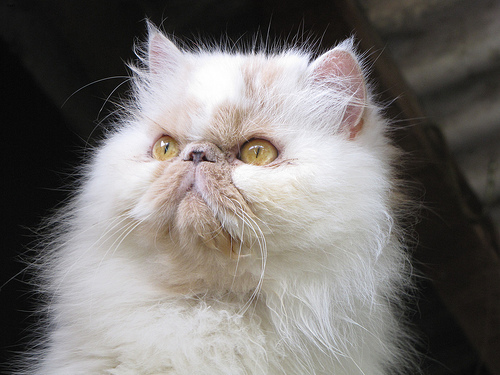

In [3]:
img = PILImage.create(path/"images/Persian_184.jpg")
mask = PILMask.create(path/"annotations/trimaps/Persian_184.png")
img


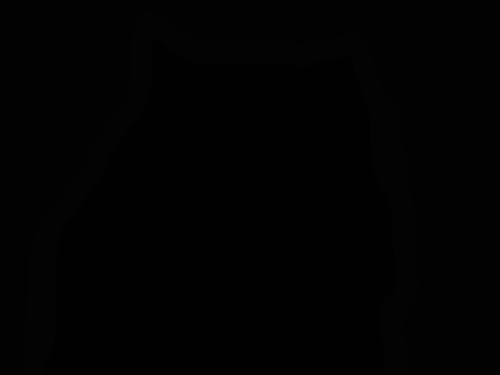

In [8]:
mask

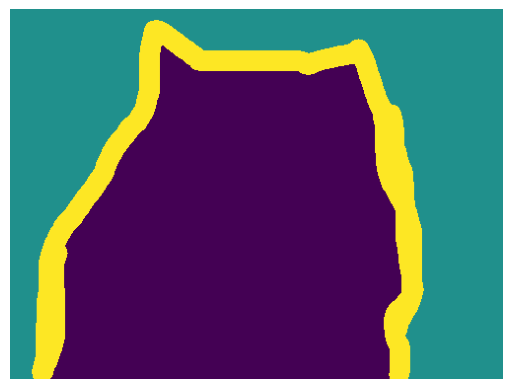

In [4]:
import matplotlib.pyplot as plt

plt.imshow(mask)
plt.axis("off");

In [4]:
fnames = get_image_files(path/"images")

def label_func(o):
    mask = PILMask.create(
        path/"annotations"/"trimaps"/f"{o.stem}.png"
    )

    mask = np.array(mask)
    mask = mask - 1

    return PILMask.create(mask)

dls = SegmentationDataLoaders.from_label_func(
    path,
    fnames,
    label_func=label_func,
    codes=['foreground', 'background', 'boundary'],
    bs=8,
    item_tfms=Resize(224)
)

x, y = dls.one_batch()

print(torch.unique(y))

TensorMask([0, 1, 2], device='cuda:0')


In [5]:
learn = unet_learner(dls, resnet34)
learn.fine_tune(2)

epoch,train_loss,valid_loss,time
0,0.288299,0.244860,04:17


epoch,train_loss,valid_loss,time
0,0.214830,0.228827,04:29
1,0.163903,0.191546,04:29
